<a href="https://colab.research.google.com/github/alivarmazyar/CMP7239-CW2/blob/main/Ali_Varmazyar_25181730.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================
# IMPORT REQUIRED LIBRARIES
# ==============================
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# System utilities
import os
import joblib
import warnings

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Traditional ML models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

# Deep learning (Autoencoder-style regression model)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Ignore warnings for cleaner output
warnings.filterwarnings("ignore")

# Create folder to store trained models
os.makedirs("saved_models", exist_ok=True)

In [2]:
# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv('/content/rt_iot2022_regression_ready_50_features.csv')

# Clean column names (remove spaces if any)
df.columns = df.columns.str.strip()

# Encode categorical variables into numeric format
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

# ==============================
# SPLIT FEATURES AND TARGET
# ==============================
# Target: flow duration (regression output)
X = df.drop('flow_duration', axis=1)
y = df['flow_duration']

# ==============================
# REMOVE LOW-VARIANCE FEATURES
# ==============================
# Removes features that carry little/no information
var_selector = VarianceThreshold(0.0)
X = pd.DataFrame(
    var_selector.fit_transform(X),
    columns=X.columns[var_selector.get_support()]
)

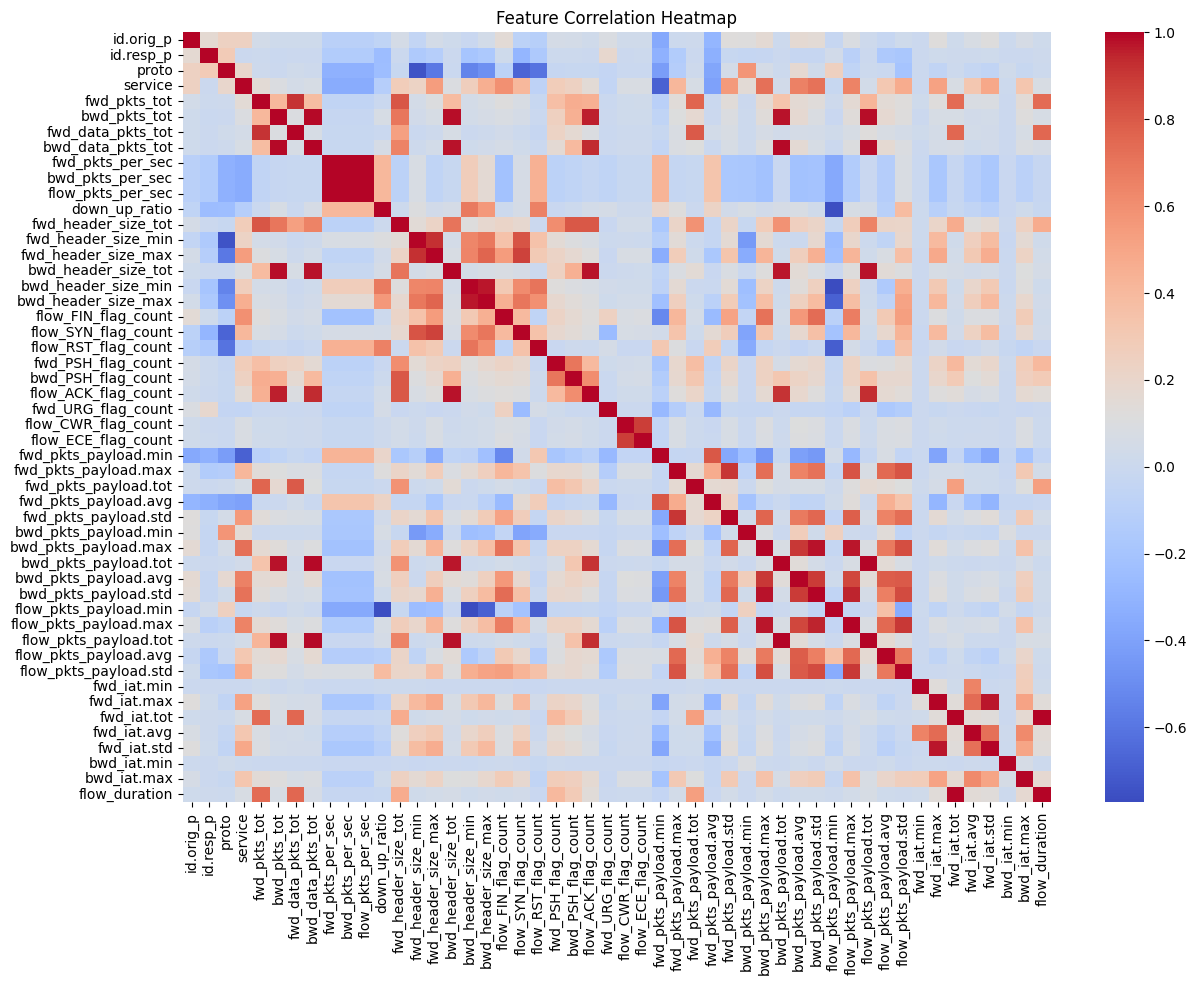

In [3]:
# ==============================
# FEATURE CORRELATION HEATMAP
# ==============================
# Helps understand relationships between variables
plt.figure(figsize=(14,10))
sns.heatmap(pd.concat([X, y], axis=1).corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
# ==============================
# EXPERIMENT SETTINGS
# ==============================
# Different feature subset sizes
feature_counts = [45, 40, 35, 30]

# Different training epochs for deep learning models
epochs_list = [15, 10, 5]

# Store all results here
results = []

In [5]:
# ==============================
# MODEL EVALUATION FUNCTION
# ==============================
# Computes regression performance metrics
def evaluate(model, y_true, y_pred):
    return {
        "Model": model,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [6]:
# ==============================
# MAIN EXPERIMENT LOOP
# ==============================
for k in feature_counts:

    print("\n" + "="*60)
    print(f"FEATURE SELECTION: TOP {k} FEATURES")
    print("="*60)

    # Split dataset into training and testing sets
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Select top-k most relevant features
    selector = SelectKBest(f_regression, k=k)

    X_train = selector.fit_transform(X_train_raw, y_train)
    X_test = selector.transform(X_test_raw)

    # Standardise data for fair model comparison
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ==============================
    # MACHINE LEARNING MODELS
    # ==============================
    ml_models = {
        "Linear_Regression": LinearRegression(),
        "Ridge_Regression": Ridge(),
        "Gradient_Boosting": GradientBoostingRegressor(random_state=42),
        "Extra_Trees": ExtraTreesRegressor(n_estimators=100, random_state=42)
    }

    for name, model in ml_models.items():

        # Train model
        model.fit(X_train, y_train)

        # Predict output
        pred = model.predict(X_test)

        # Save trained model
        joblib.dump(model, f"saved_models/{name}_{k}_features.pkl")

        # Store evaluation results
        res = evaluate(name, y_test, pred)
        res["Features"] = k
        res["Epochs"] = "-"
        results.append(res)

    # ==============================
    # DEEP LEARNING MODELS
    # ==============================
    for epoch in epochs_list:

        # ---- MLP REGRESSOR ----
        mlp = MLPRegressor(
            hidden_layer_sizes=(128,64),
            max_iter=epoch,
            random_state=42
        )

        mlp.fit(X_train, y_train)
        pred = mlp.predict(X_test)

        joblib.dump(mlp, f"saved_models/MLP_{k}_features_{epoch}_epochs.pkl")

        res = evaluate("MLP", y_test, pred)
        res["Features"] = k
        res["Epochs"] = epoch
        results.append(res)

        # ---- AUTOENCODER REGRESSION MODEL ----
        inp = Input(shape=(X_train.shape[1],))
        x = Dense(32, activation='relu')(inp)
        x = Dense(16, activation='relu')(x)
        x = Dense(8, activation='relu')(x)
        out = Dense(1)(x)

        auto = Model(inp, out)
        auto.compile(optimizer='adam', loss='mse')

        auto.fit(X_train, y_train, epochs=epoch, verbose=0)

        pred = auto.predict(X_test).flatten()

        auto.save(f"saved_models/Autoencoder_{k}_features_{epoch}_epochs.h5")

        res = evaluate("Autoencoder", y_test, pred)
        res["Features"] = k
        res["Epochs"] = epoch
        results.append(res)


FEATURE SELECTION: TOP 45 FEATURES
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  



FEATURE SELECTION: TOP 40 FEATURES
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


...

770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


770/770 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step



FEATURE SELECTION: TOP 30 FEATURES
770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [7]:
# ==============================
# CONVERT RESULTS TO DATAFRAME
# ==============================
results_df = pd.DataFrame(results).round(4)

In [8]:
# ==============================
# DISPLAY RESULTS PER FEATURE SET
# ==============================
for k in feature_counts:
    print("\n" + "="*60)
    print(f"RESULTS ({k} FEATURES)")
    print("="*60)

    display(
        results_df[results_df["Features"] == k]
        .sort_values(by="R2", ascending=False)
    )


RESULTS (45 FEATURES)


,Model,MAE,RMSE,R2,Features,Epochs
3,Extra_Trees,0.0322,1.5484,0.9922,45,-
2,Gradient_Boosting,0.1044,1.5852,0.9919,45,-
1,Ridge_Regression,0.2387,4.4501,0.9358,45,-
0,Linear_Regression,0.2387,4.4496,0.9358,45,-
4,MLP,1.1004,6.9080,0.8454,45,15
5,Autoencoder,0.8074,7.0673,0.8382,45,15
9,Autoencoder,1.4092,11.1579,0.5966,45,5
7,Autoencoder,1.1472,11.3187,0.5849,45,10
6,MLP,3.7129,13.7693,0.3857,45,10
8,MLP,2.1495,17.0049,0.0631,45,5



RESULTS (40 FEATURES)


,Model,MAE,RMSE,R2,Features,Epochs
13,Extra_Trees,0.0252,0.9434,0.9971,40,-
12,Gradient_Boosting,0.1012,1.5696,0.9920,40,-
11,Ridge_Regression,0.2761,4.4937,0.9346,40,-
10,Linear_Regression,0.2760,4.4930,0.9346,40,-
15,Autoencoder,1.0068,7.7925,0.8033,40,15
16,MLP,1.2904,8.5130,0.7652,40,10
14,MLP,1.5858,9.9411,0.6798,40,15
19,Autoencoder,1.7884,14.4052,0.3276,40,5
18,MLP,3.1360,15.8743,0.1835,40,5
17,Autoencoder,5.9428,16.1215,0.1579,40,10



RESULTS (35 FEATURES)


,Model,MAE,RMSE,R2,Features,Epochs
23,Extra_Trees,0.0249,1.0609,0.9964,35,-
22,Gradient_Boosting,0.0995,1.4427,0.9933,35,-
21,Ridge_Regression,0.2349,4.5711,0.9323,35,-
20,Linear_Regression,0.2355,4.5709,0.9323,35,-
25,Autoencoder,0.6730,7.9136,0.7971,35,15
27,Autoencoder,1.1388,8.1376,0.7854,35,10
24,MLP,2.5062,9.5336,0.7055,35,15
26,MLP,1.5587,9.7747,0.6904,35,10
29,Autoencoder,2.0079,15.9585,0.1748,35,5
28,MLP,2.7177,26.8170,-1.3301,35,5



RESULTS (30 FEATURES)


,Model,MAE,RMSE,R2,Features,Epochs
33,Extra_Trees,0.0233,0.8450,0.9977,30,-
32,Gradient_Boosting,0.0957,1.3580,0.9940,30,-
31,Ridge_Regression,0.1829,4.6637,0.9295,30,-
30,Linear_Regression,0.1830,4.6638,0.9295,30,-
35,Autoencoder,0.8197,6.2118,0.8750,30,15
34,MLP,1.2619,7.0918,0.8370,30,15
37,Autoencoder,0.7873,7.6144,0.8121,30,10
36,MLP,1.0743,10.7378,0.6264,30,10
39,Autoencoder,2.4917,13.6470,0.3966,30,5
38,MLP,3.2593,19.6607,-0.2524,30,5


In [9]:
# ==============================
# PIVOT TABLES FOR ANALYSIS
# ==============================
r2_table = results_df.pivot_table(index="Features", columns="Model", values="R2")
mae_table = results_df.pivot_table(index="Features", columns="Model", values="MAE")
rmse_table = results_df.pivot_table(index="Features", columns="Model", values="RMSE")

# ==============================
# BEST OVERALL SUMMARY
# ==============================
best_summary = pd.DataFrame({
    "Best R2": r2_table.max(),
    "Best MAE": mae_table.min(),
    "Best RMSE": rmse_table.min()
})

display(best_summary)

,Best R2,Best MAE,Best RMSE
Model,,,
Autoencoder,0.694567,1.121267,9.157733
Extra_Trees,0.997700,0.023300,0.845000
Gradient_Boosting,0.994000,0.095700,1.358000
Linear_Regression,0.935800,0.183000,4.449600
MLP,0.542833,1.865167,11.442800
Ridge_Regression,0.935800,0.182900,4.450100


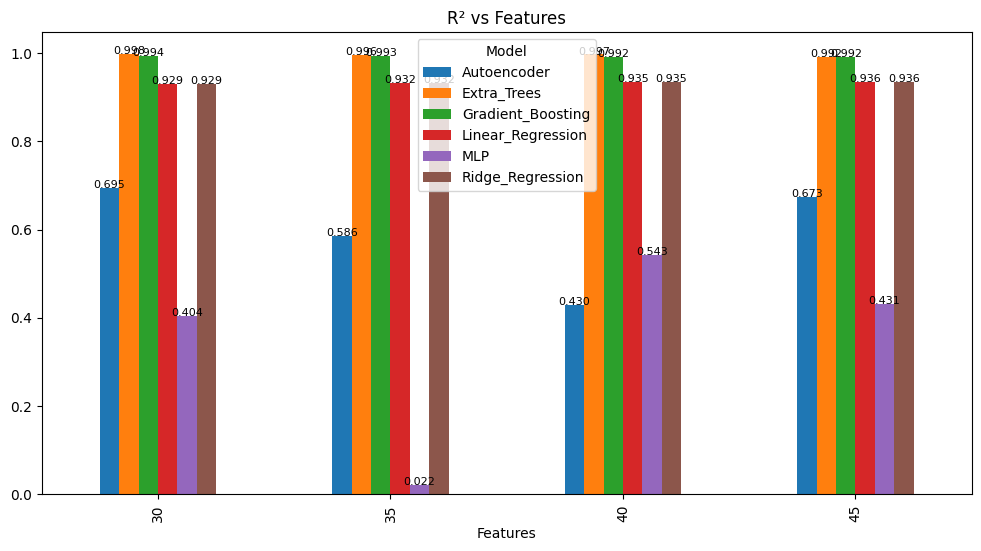

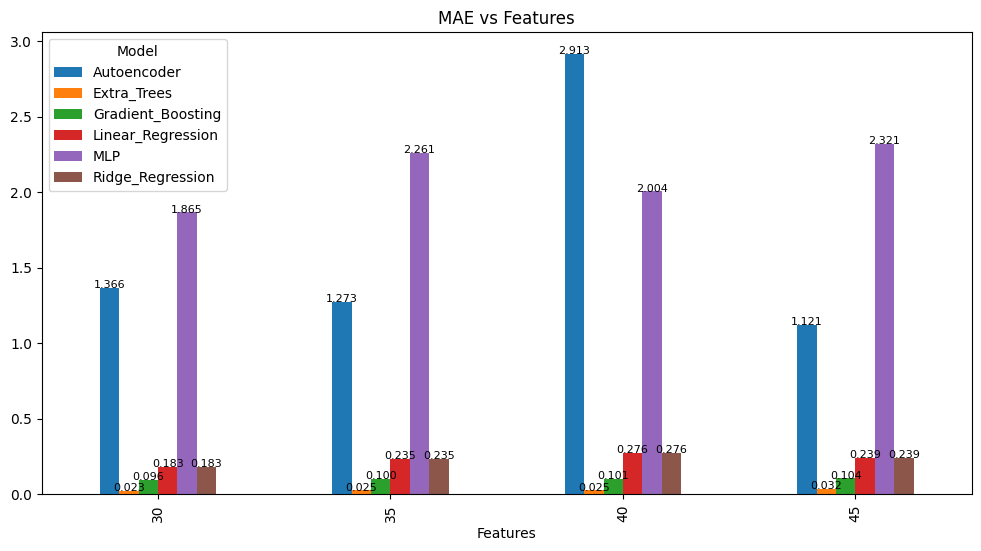

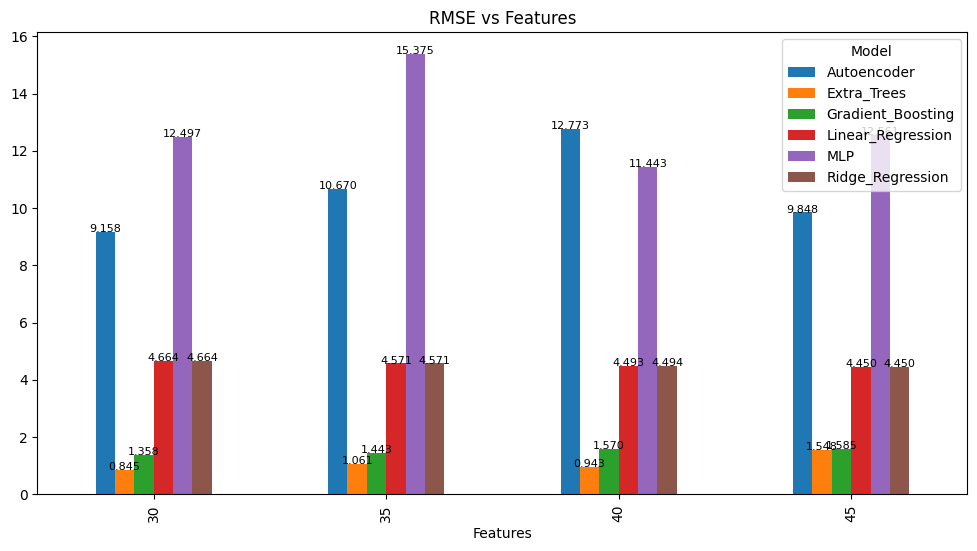

In [10]:
# ==============================
# FUNCTION TO ADD VALUES ON BARS
# ==============================
def add_labels(ax):
    for container in ax.containers:
        for bar in container:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2,
                    h,
                    f"{h:.3f}",
                    ha='center',
                    fontsize=8)

# ==============================
# R² PLOT
# ==============================
fig, ax = plt.subplots(figsize=(12,6))
r2_table.plot(kind='bar', ax=ax)
add_labels(ax)
plt.title("R² vs Features")
plt.show()

# ==============================
# MAE PLOT
# ==============================
fig, ax = plt.subplots(figsize=(12,6))
mae_table.plot(kind='bar', ax=ax)
add_labels(ax)
plt.title("MAE vs Features")
plt.show()

# ==============================
# RMSE PLOT
# ==============================
fig, ax = plt.subplots(figsize=(12,6))
rmse_table.plot(kind='bar', ax=ax)
add_labels(ax)
plt.title("RMSE vs Features")
plt.show()

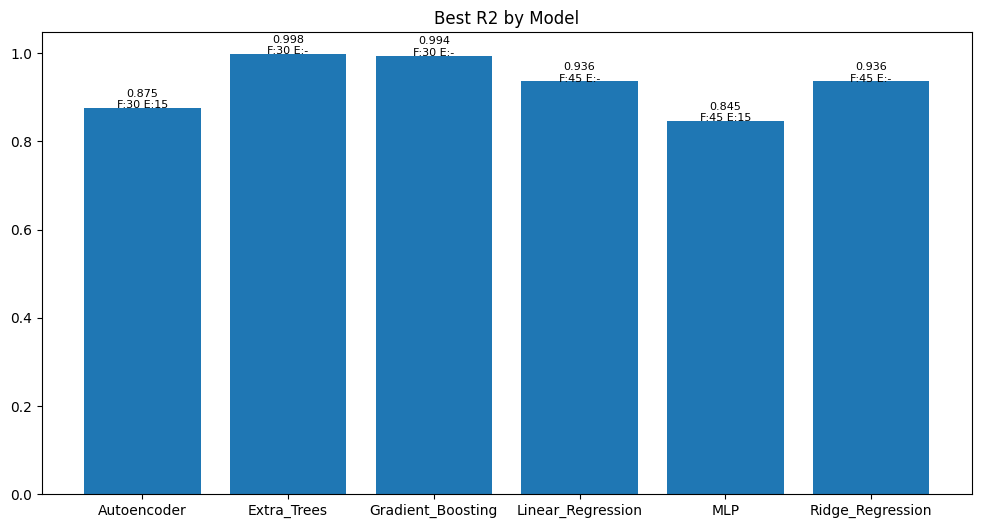

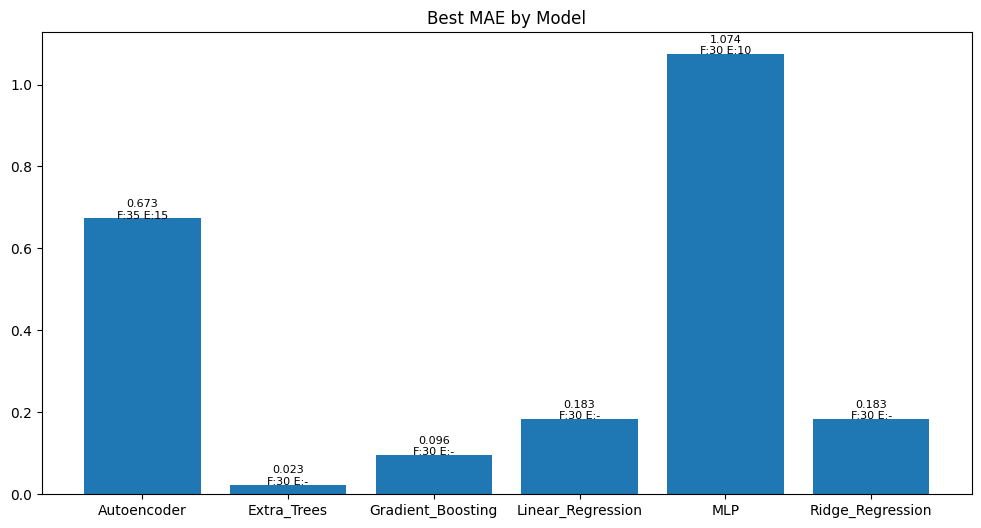

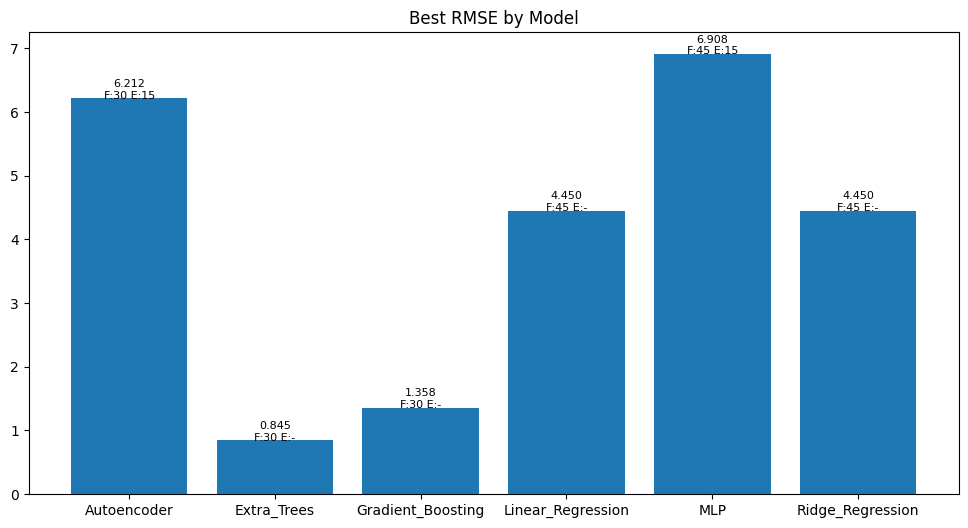

In [11]:
# ==============================
# BEST MODEL PER METRIC
# ==============================
best_r2 = results_df.loc[results_df.groupby("Model")["R2"].idxmax()]
best_mae = results_df.loc[results_df.groupby("Model")["MAE"].idxmin()]
best_rmse = results_df.loc[results_df.groupby("Model")["RMSE"].idxmin()]

# ==============================
# FUNCTION TO PLOT BEST MODELS
# ==============================
def plot_best(data, metric):
    plt.figure(figsize=(12,6))
    bars = plt.bar(data["Model"], data[metric])

    for i, bar in enumerate(bars):
        r = data.iloc[i]
        plt.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height(),
                 f"{r[metric]:.3f}\nF:{r['Features']} E:{r['Epochs']}",
                 ha='center', fontsize=8)

    plt.title(f"Best {metric} by Model")
    plt.show()

# ==============================
# PLOT BEST RESULTS
# ==============================
plot_best(best_r2, "R2")
plot_best(best_mae, "MAE")
plot_best(best_rmse, "RMSE")